In [3]:
!pip install tensorflow
!pip install pandas
#Añadimos estas dos líneas adicionales para que uséis la misma versión que uso yo en el curso, la 2.3.0
#En 2023 lo hemos actualizado para que uses las últimas versiones, probado en la 2.8.0
#De momento han dejado de funcionar los callbacks y el guardado a fichero JSON (aún no sabemos por qué)

!pip install tensorflow==2.8.0
!pip install keras==2.8.0




ERROR: Could not find a version that satisfies the requirement tensorflow==2.8.0 (from versions: 2.12.0rc0, 2.12.0rc1, 2.12.0, 2.12.1, 2.13.0rc0, 2.13.0rc1, 2.13.0rc2, 2.13.0, 2.13.1, 2.14.0rc0, 2.14.0rc1, 2.14.0, 2.14.1, 2.15.0rc0, 2.15.0rc1, 2.15.0, 2.15.0.post1, 2.15.1, 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.8.0
  Using cached keras-2.8.0-py2.py3-none-any.whl.metadata (1.3 kB)
Using cached keras-2.8.0-py2.py3-none-any.whl (1.4 MB)
  Attempting uninstall: keras
    Found existing installation: keras 2.15.0
    Uninstalling keras-2.15.0:
ERROR: Could not install packages due to an OSError: [Errno 13] Permission denied: 'METADATA'
Consider using the `--user` option or check the permissions.



In [76]:
import pandas as pd
import numpy as np
import os
import PIL
import seaborn as sns
import pickle
from PIL import *
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler
from IPython.display import display
#from tensorflow.python.keras import * -> PARA LAS NUEVAS VERSIONES DE TF, HACE QUE NO FUNCIONE
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, optimizers
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import *
from tensorflow.keras import backend as K
#from keras import optimizers -> PARA LAS NUEVAS VERSIONES DE TF, HACE QUE NO FUNCIONE
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
#from google.colab.patches import cv2_imshow

In [77]:
keyfacial_df = pd.read_csv('../dataset/data.csv')

In [78]:
keyfacial_df

,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y,Image
0,66.033564,39.002274,30.227008,36.421678,59.582075,39.647423,73.130346,39.969997,36.356571,37.389402,...,57.066803,61.195308,79.970165,28.614496,77.388992,43.312602,72.935459,43.130707,84.485774,238 236 237 238 240 240 239 241 241 243 240 23...
1,64.332936,34.970077,29.949277,33.448715,58.856170,35.274349,70.722723,36.187166,36.034723,34.361532,...,55.660936,56.421447,76.352000,35.122383,76.047660,46.684596,70.266553,45.467915,85.480170,219 215 204 196 204 211 212 200 180 168 178 19...
2,65.057053,34.909642,30.903789,34.909642,59.412000,36.320968,70.984421,36.320968,37.678105,36.320968,...,53.538947,60.822947,73.014316,33.726316,72.732000,47.274947,70.191789,47.274947,78.659368,144 142 159 180 188 188 184 180 167 132 84 59 ...
3,65.225739,37.261774,32.023096,37.261774,60.003339,39.127179,72.314713,38.380967,37.618643,38.754115,...,54.166539,65.598887,72.703722,37.245496,74.195478,50.303165,70.091687,51.561183,78.268383,193 192 193 194 194 194 193 192 168 111 50 12 ...
4,66.725301,39.621261,32.244810,38.042032,58.565890,39.621261,72.515926,39.884466,36.982380,39.094852,...,64.889521,60.671411,77.523239,31.191755,76.997301,44.962748,73.707387,44.227141,86.871166,147 148 160 196 215 214 216 217 219 220 206 18...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2135,67.180378,35.816373,33.239956,34.921932,59.347973,37.000904,72.667896,37.097600,39.404349,36.589944,...,60.065396,64.397610,73.248393,35.446431,74.014748,48.708626,76.760852,48.559612,77.335618,191 191 191 190 189 185 184 120 54 34 19 24 31...
2136,65.724490,36.301020,25.377551,37.311224,58.530612,37.739796,74.448980,37.525510,33.551020,38.107143,...,62.472789,66.928121,79.229046,28.015377,81.151722,48.771976,81.816774,49.287271,82.871156,19 19 19 18 13 7 3 4 3 1 3 9 11 12 12 13 10 9 ...
2137,68.430866,38.651975,28.895857,37.617027,61.659350,40.100902,75.586792,40.219182,37.665118,39.087245,...,63.289576,68.864397,77.495823,22.013981,77.368995,49.180628,79.043130,47.176739,89.544522,31 40 47 31 54 58 63 100 86 80 82 75 79 86 90 ...
2138,64.152180,30.691592,27.000898,40.868082,56.505624,34.126963,73.436776,28.556335,34.746122,40.506939,...,59.735799,73.730743,70.273886,38.777143,80.684286,58.042857,79.301429,58.611086,80.355543,7 1 5 1 3 20 12 0 5 8 6 18 13 9 8 12 12 11 4 8...


In [79]:
keyfacial_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2140 entries, 0 to 2139
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   left_eye_center_x          2140 non-null   float64
 1   left_eye_center_y          2140 non-null   float64
 2   right_eye_center_x         2140 non-null   float64
 3   right_eye_center_y         2140 non-null   float64
 4   left_eye_inner_corner_x    2140 non-null   float64
 5   left_eye_inner_corner_y    2140 non-null   float64
 6   left_eye_outer_corner_x    2140 non-null   float64
 7   left_eye_outer_corner_y    2140 non-null   float64
 8   right_eye_inner_corner_x   2140 non-null   float64
 9   right_eye_inner_corner_y   2140 non-null   float64
 10  right_eye_outer_corner_x   2140 non-null   float64
 11  right_eye_outer_corner_y   2140 non-null   float64
 12  left_eyebrow_inner_end_x   2140 non-null   float64
 13  left_eyebrow_inner_end_y   2140 non-null   float

In [80]:
keyfacial_df['Image'].shape

(2140,)

In [81]:
keyfacial_df['Image'] = keyfacial_df['Image'].apply(lambda x: np.fromstring(x, dtype = int, sep = ' ').reshape(96, 96))

In [82]:
keyfacial_df['Image'][0].shape

(96, 96)

In [83]:
#MINI RETO #1:

#Obtenga los valores promedio, mínimo y máximo para right_eye_center_x.

In [84]:
keyfacial_df.describe()

,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_x,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y
count,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,...,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000
mean,66.221549,36.842274,29.640269,37.063815,59.272128,37.856014,73.412473,37.640110,36.603107,37.920852,...,47.952141,57.253926,63.419076,75.887660,32.967365,76.134065,48.081325,72.681125,48.149654,82.630412
std,2.087683,2.294027,2.051575,2.234334,2.005631,2.034500,2.701639,2.684162,1.822784,2.009505,...,3.276053,4.528635,3.650131,4.438565,3.595103,4.259514,2.723274,5.108675,3.032389,4.813557
min,47.835757,23.832996,18.922611,24.773072,41.779381,27.190098,52.947144,26.250023,24.112624,26.250023,...,24.472590,41.558400,43.869480,57.023258,9.778137,56.690208,32.260312,56.719043,33.047605,57.232296
25%,65.046300,35.468842,28.472224,35.818377,58.113054,36.607950,71.741978,36.102409,35.495730,36.766783,...,46.495330,54.466000,61.341291,72.874263,30.879288,73.280038,46.580004,69.271669,46.492000,79.417480
50%,66.129065,36.913319,29.655440,37.048085,59.327154,37.845220,73.240045,37.624207,36.620735,37.920336,...,47.900511,57.638582,63.199057,75.682465,33.034022,75.941985,47.939031,72.395978,47.980854,82.388899
75%,67.332093,38.286438,30.858673,38.333884,60.521492,39.195431,74.978684,39.308331,37.665280,39.143921,...,49.260657,60.303524,65.302398,78.774969,35.063575,78.884031,49.290000,75.840286,49.551936,85.697976
max,78.013082,46.132421,42.495172,45.980981,69.023030,47.190316,87.032252,49.653825,47.293746,44.887301,...,65.279654,75.992731,84.767123,94.673637,50.973348,93.443176,61.804506,93.916338,62.438095,95.808983


In [85]:
mean_val = keyfacial_df["right_eye_center_x"].mean()
min_val = keyfacial_df["right_eye_center_x"].min()
max_val = keyfacial_df["right_eye_center_x"].max()

print("Promedio:", mean_val)
print("Mínimo:", min_val)
print("Máximo:", max_val)


Promedio: 29.640268564561495
Mínimo: 18.9226106286
Máximo: 42.495171727


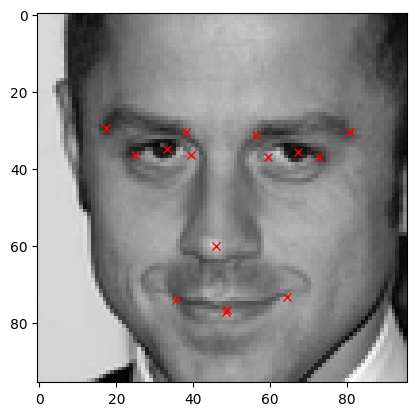

In [86]:
# Representamos una imagen aleatoria del conjunto de datos junto con puntos clave faciales.
# Los datos de la imagen se obtienen de df ['Image'] y se representan usando plt.imshow
# 15 coordenadas x e y para la imagen correspondiente
# Dado que las coordenadas x están en columnas pares como 0,2,4, .. y las coordenadas y están en columnas impares como 1,3,5, ..
# Accedemos a su valor usando el comando .loc, que obtiene los valores de las coordenadas de la imagen en función de la columna a la que se refiere.

import matplotlib.pyplot as plt



i = np.random.randint(1, len(keyfacial_df))
plt.imshow(keyfacial_df['Image'][i], cmap = 'gray')
for j in range(1, 31, 2):
    #plt.plot(keyfacial_df.loc[i][j-1], keyfacial_df.loc[i][j], 'rx')
    plt.plot(keyfacial_df.loc[i].iloc[j-1], keyfacial_df.loc[i].iloc[j], 'rx')




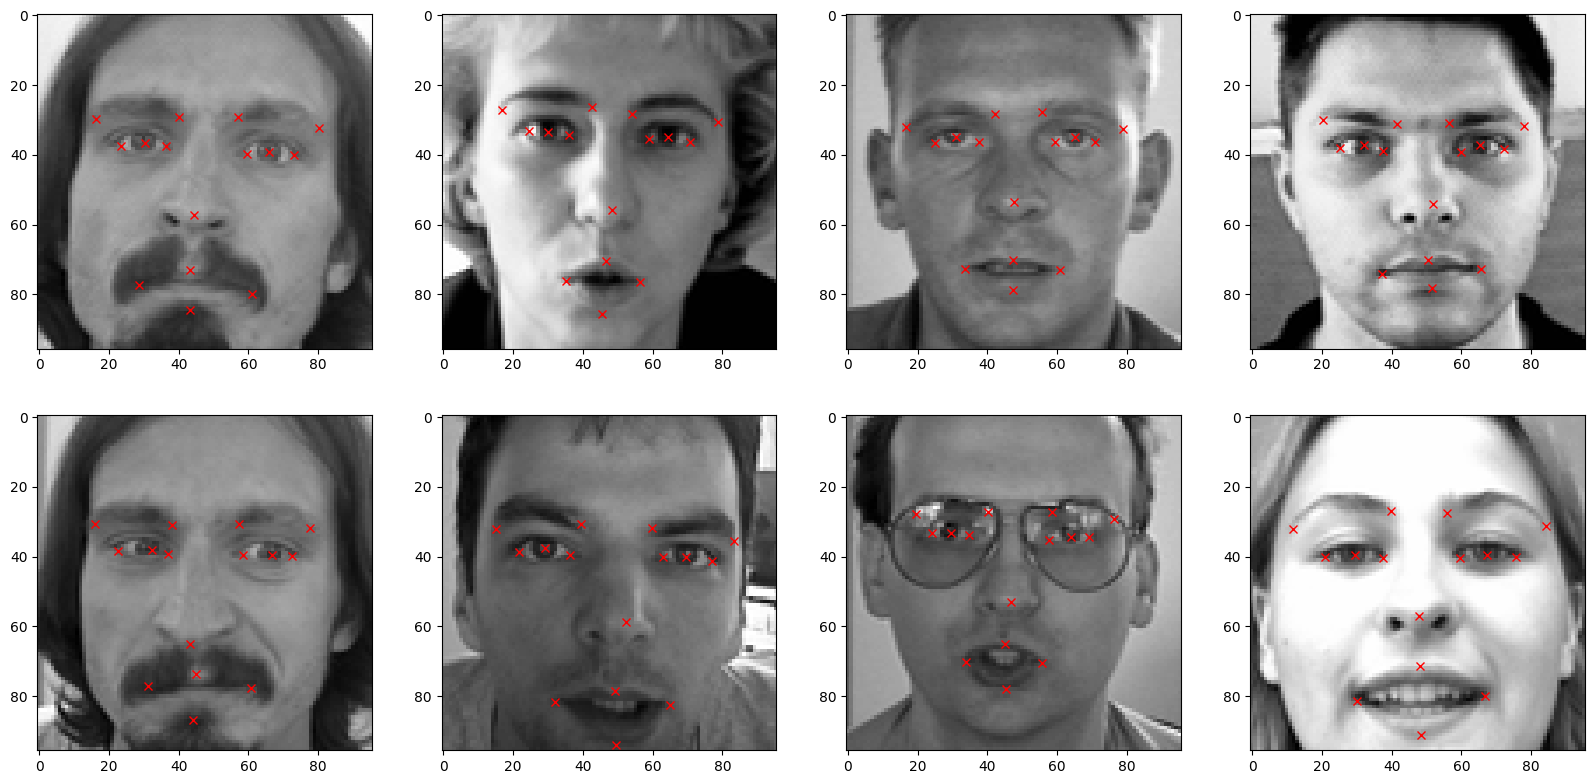

In [87]:
# Veamos más imágenes en formato matricial
fig = plt.figure(figsize=(20, 20))

for i in range(8):
    ax = fig.add_subplot(4, 4, i + 1)
    image = plt.imshow(keyfacial_df['Image'][i],cmap = 'gray')
    for j in range(1, 31, 2):
        fila = keyfacial_df.loc[i]   # esto sigue siendo una Series
        plt.plot(fila.iloc[j-1], fila.iloc[j], 'rx')

        

In [88]:
#MINI RETO #2:

#Realiza una verificación adicional en los datos visualizando aleatoriamente 64 nuevas imágenes junto con sus puntos clave correspondientes



In [89]:
# Creamos una copia del dataframe
import copy
keyfacial_df_copy = copy.copy(keyfacial_df)

In [90]:
# Obtenemos las columnas del dataframe

columns = keyfacial_df_copy.columns[:-1]
columns

Index(['left_eye_center_x', 'left_eye_center_y', 'right_eye_center_x',
       'right_eye_center_y', 'left_eye_inner_corner_x',
       'left_eye_inner_corner_y', 'left_eye_outer_corner_x',
       'left_eye_outer_corner_y', 'right_eye_inner_corner_x',
       'right_eye_inner_corner_y', 'right_eye_outer_corner_x',
       'right_eye_outer_corner_y', 'left_eyebrow_inner_end_x',
       'left_eyebrow_inner_end_y', 'left_eyebrow_outer_end_x',
       'left_eyebrow_outer_end_y', 'right_eyebrow_inner_end_x',
       'right_eyebrow_inner_end_y', 'right_eyebrow_outer_end_x',
       'right_eyebrow_outer_end_y', 'nose_tip_x', 'nose_tip_y',
       'mouth_left_corner_x', 'mouth_left_corner_y', 'mouth_right_corner_x',
       'mouth_right_corner_y', 'mouth_center_top_lip_x',
       'mouth_center_top_lip_y', 'mouth_center_bottom_lip_x',
       'mouth_center_bottom_lip_y'],
      dtype='object')

In [91]:
# Horizontal Flip - Damos la vuelta a las imágenes entorno al eje y
keyfacial_df_copy['Image'] = keyfacial_df_copy['Image'].apply(lambda x: np.flip(x, axis = 1))

# dado que estamos volteando horizontalmente, los valores de la coordenada y serían los mismos
# Solo cambiarían los valores de la coordenada x, todo lo que tenemos que hacer es restar nuestros valores iniciales de la coordenada x del ancho de la imagen (96)
for i in range(len(columns)):
  if i%2 == 0:
    keyfacial_df_copy[columns[i]] = keyfacial_df_copy[columns[i]].apply(lambda x: 96. - float(x) )

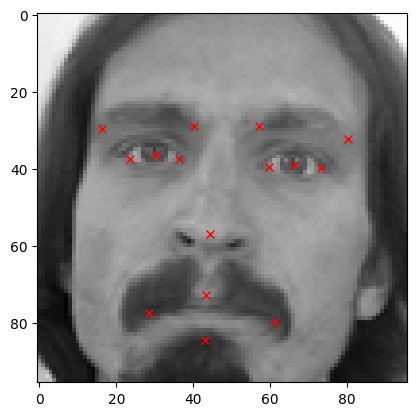

In [92]:
# Mostramos la imagen original
plt.imshow(keyfacial_df['Image'][0], cmap = 'gray')
for j in range(1, 31, 2):
    fila = keyfacial_df.loc[0]   # obtienes la fila como Series
    plt.plot(fila.iloc[j-1], fila.iloc[j], 'rx')

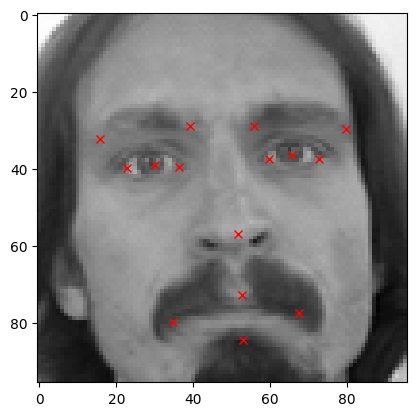

In [93]:
# Mostramos la imagen girada horizontalmente
# se uso el for mas expresivo 
plt.imshow(keyfacial_df_copy['Image'].iloc[0], cmap='gray')
fila = keyfacial_df_copy.loc[0]

for j in range(1, 31, 2):
    x = fila.iloc[j-1]
    y = fila.iloc[j]
    plt.plot(x, y, 'rx')

In [94]:
# Concatenamos el dataset original con el dataframe aumentado
augmented_df = np.concatenate((keyfacial_df, keyfacial_df_copy))

In [95]:
augmented_df.shape

(4280, 31)

In [96]:
# Aumentar aleatoriamente el brillo de las imágenes
# Multiplicamos los valores de los píxeles por valores aleatorios entre 1,5 y 2 para aumentar el brillo de la imagen
# Recortamos el valor entre 0 y 255

import random

keyfacial_df_copy = copy.copy(keyfacial_df)
keyfacial_df_copy['Image'] = keyfacial_df_copy['Image'].apply(lambda x:np.clip(random.uniform(1.5, 2)* x, 0.0, 255.0))
augmented_df = np.concatenate((augmented_df, keyfacial_df_copy))
augmented_df.shape

(6420, 31)

/tmp/ipykernel_1249/432438030.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(keyfacial_df_copy.loc[0][j-1], keyfacial_df_copy.loc[0][j], 'rx')


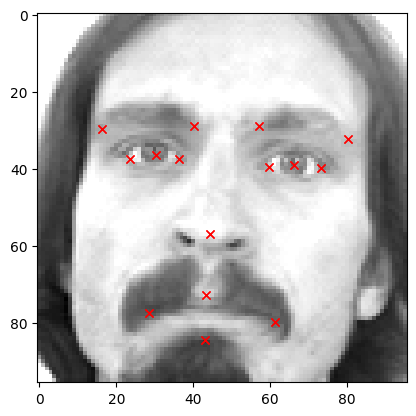

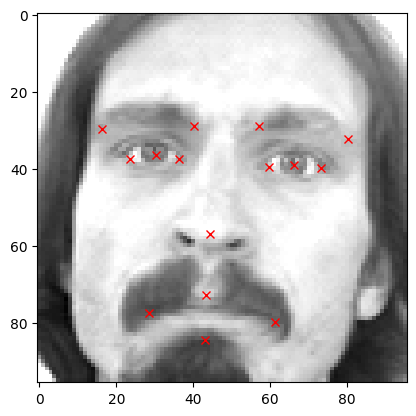

In [97]:
# Mostramos la imagen con el brillo aumentado

plt.imshow(keyfacial_df_copy['Image'][0], cmap='gray')
for j in range(1, 31, 2):
    plt.plot(keyfacial_df_copy.loc[0][j-1], keyfacial_df_copy.loc[0][j], 'rx')


def plot_facial_landmarks(df, index=0):
    plt.imshow(df['Image'].iloc[index], cmap='gray')
    fila = df.loc[index]
    for j in range(1, 31, 2):
        plt.plot(fila.iloc[j-1], fila.iloc[j], 'rx')
    plt.show()

# Uso:
plot_facial_landmarks(keyfacial_df_copy, 0)


plt.imshow(keyfacial_df_copy['Image'].iloc[0], cmap='gray')
fila = keyfacial_df_copy.loc[0]
for j in range(1, 31, 2):
    x = fila.iloc[j-1]
    y = fila.iloc[j]
    plt.plot(x, y, 'rx')



In [98]:
#MINI RETO #3:

#Aumenta las imágenes volteándolas verticalmente (Sugerencia: voltea a lo 
#largo del eje x y ten en cuenta que si lo hacemos a lo largo del eje x, 
#las coordenadas x no cambiarán)


In [99]:

# aca 
import numpy as np
import matplotlib.pyplot as plt

class FacialAugmentor:
    def __init__(self, df):
        """
        Inicializa con un DataFrame que contiene:
        - Columna 'Image' con imágenes en formato numpy array
        - Columnas con coordenadas faciales (x,y)
        """
        self.df = df

    def flip_vertical(self, index=0):
        """
        Voltea verticalmente la imagen y ajusta los landmarks faciales.
        Retorna imagen volteada y lista de coordenadas ajustadas.
        """
        img = np.flipud(self.df['Image'].iloc[index])
        fila = self.df.loc[index]
        img_height = img.shape[0]

        coords = []
        for j in range(1, 31, 2):
            x = fila.iloc[j-1]   # x se mantiene igual
            y = img_height - fila.iloc[j]  # y se refleja
            coords.append((x, y))
        return img, coords

    def plot_landmarks(self, img, coords):
        """
        Grafica la imagen y los landmarks faciales.
        """
        plt.imshow(img, cmap='gray')
        for (x, y) in coords:
            plt.plot(x, y, 'rx')
        plt.show()




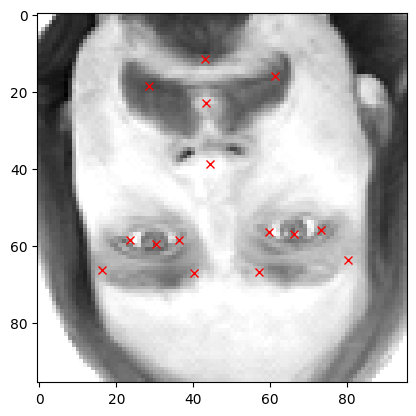

In [100]:
# Inicializamos con el DataFrame
augmentor = FacialAugmentor(keyfacial_df_copy)

# Volteamos verticalmente la primera imagen
img, coords = augmentor.flip_vertical(index=0)

# Graficamos la imagen con landmarks
augmentor.plot_landmarks(img, coords)


In [101]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Función segura para convertir strings en arrays 96x96 ---
def parse_image_safe(im_str):
    im_str = str(im_str).strip()
    if not im_str:
        return None
    vals = im_str.split()
    if len(vals) != 96*96:   # solo aceptamos filas con 9216 valores
        return None
    arr = np.array(vals, dtype=np.uint8)
    return arr.reshape(96,96)

# --- 2. Crear columna auxiliar con conteo de valores ---
keyfacial_df_copy['count_vals'] = keyfacial_df_copy['Image'].apply(lambda s: len(str(s).split()))

# --- 3. Filtrar filas con exactamente 9216 valores ---
valid_rows = keyfacial_df_copy[keyfacial_df_copy['count_vals'] == 96*96].copy()

# --- 4. Convertir las cadenas en arrays ---
valid_rows['Image'] = valid_rows['Image'].apply(parse_image_safe)

print("Número de imágenes válidas:", len(valid_rows))

# --- 5. Clase para augmentación ---
class FacialAugmentor:
    def __init__(self, df):
        """
        Inicializa con un DataFrame que contiene:
        - Columna 'Image' con imágenes en formato numpy array
        - Columnas con coordenadas faciales (x,y)
        """
        self.df = df

    def flip_vertical(self, index=0):
        """
        Voltea verticalmente la imagen y ajusta los landmarks faciales.
        Retorna imagen volteada y lista de coordenadas ajustadas.
        """
        img = np.flipud(self.df['Image'].iloc[index])
        fila = self.df.iloc[index]
        img_height = img.shape[0]

        coords = []
        for j in range(1, 31, 2):  # suponiendo 15 pares (x,y)
            x = fila.iloc[j-1]   # x se mantiene igual
            y = img_height - fila.iloc[j]  # y se refleja
            coords.append((x, y))
        return img, coords

    def plot_landmarks(self, img, coords):
        """
        Grafica la imagen y los landmarks faciales.
        """
        plt.imshow(img, cmap='gray')
        for (x, y) in coords:
            plt.plot(x, y, 'rx')
        plt.show()

# --- 6. Usar la clase con el DataFrame ya limpio ---
if len(valid_rows) > 0:
    augmentor = FacialAugmentor(valid_rows)
    img, coords = augmentor.flip_vertical(index=0)
    augmentor.plot_landmarks(img, coords)
else:
    print("No hay imágenes válidas en el dataset 2.")

Número de imágenes válidas: 0
No hay imágenes válidas en el dataset 2.


/tmp/ipykernel_1249/3595391385.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(keyfacial_df_copy.loc[0][j-1], keyfacial_df_copy.loc[0][j], 'rx')


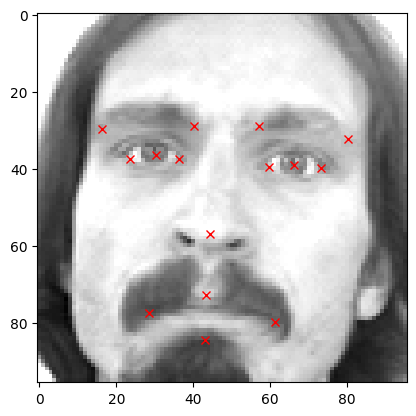

In [102]:
plt.imshow(keyfacial_df_copy['Image'][0], cmap='gray')
for j in range(1, 31, 2):
        plt.plot(keyfacial_df_copy.loc[0][j-1], keyfacial_df_copy.loc[0][j], 'rx')